# 3. Entrenamiento de Modelos

Este notebook implementa el pipeline de entrenamiento para la detección de exoplanetas.

## Estructura

1. **Cargar datos**: Leer los CSVs preprocesados
2. **DataLoaders**: Crear datasets y dataloaders de PyTorch
3. **Definir modelo**: LSTM básico para empezar
4. **Training loop**: Con early stopping y métricas por época
5. **Evaluación**: Métricas finales en test

## 3.1 Imports y configuración

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import pandas as pd
import numpy as np
from pathlib import Path
import time
from tqdm import tqdm

from sklearn.metrics import (
    accuracy_score, 
    precision_recall_fscore_support,
    classification_report,
    roc_auc_score,
    average_precision_score
)

# Configuración
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# Directorios
DATA_DIR = Path("data/processed")
MODELS_DIR = Path("models")
MODELS_DIR.mkdir(exist_ok=True)

print("✓ Librerías cargadas")

Device: cuda
✓ Librerías cargadas


## 3.2 Cargar datos

In [2]:
# Cargar CSVs
print("Cargando datos...")
df_train = pd.read_csv(DATA_DIR / "train.csv")
df_val = pd.read_csv(DATA_DIR / "val.csv")
df_test = pd.read_csv(DATA_DIR / "test.csv")

print(f"✓ Train: {len(df_train):,} samples")
print(f"✓ Val: {len(df_val):,} samples")
print(f"✓ Test: {len(df_test):,} samples")

# Identificar columnas de features
global_cols = [c for c in df_train.columns if c.startswith('global_')]
local_cols = [c for c in df_train.columns if c.startswith('local_')]

print(f"\nFeatures:")
print(f"  - Global view: {len(global_cols)} features")
print(f"  - Local view: {len(local_cols)} features")

# Distribución de clases
print(f"\nDistribución de clases (Train):")
print(df_train['av_training_set'].value_counts())
n_pos = df_train['label'].sum()
n_neg = len(df_train) - n_pos
print(f"  Ratio desbalance: 1:{n_neg/n_pos:.3f}")

Cargando datos...
✓ Train: 12,589 samples
✓ Val: 1,574 samples
✓ Test: 1,574 samples

Features:
  - Global view: 2001 features
  - Local view: 201 features

Distribución de clases (Train):
av_training_set
AFP    7643
PC     2885
NTP    2061
Name: count, dtype: int64
  Ratio desbalance: 1:3.364


## 3.3 Dataset y DataLoaders

In [3]:
class ExoplanetDataset(Dataset):
    """
    Dataset para curvas de luz de Kepler.
    Puede usar global_view, local_view o ambas.
    """
    def __init__(self, df: pd.DataFrame, feature_cols: list[str]):
        self.features = torch.tensor(df[feature_cols].values, dtype=torch.float32)
        self.labels = torch.tensor(df['label'].values, dtype=torch.float32)
    
    def __len__(self) -> int:
        return len(self.labels)
    
    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        return self.features[idx], self.labels[idx]


def create_dataloaders(
    df_train: pd.DataFrame, 
    df_val: pd.DataFrame, 
    df_test: pd.DataFrame,
    feature_cols: list[str],
    batch_size: int = 32,
    use_stratified_sampling: bool = True
) -> tuple[DataLoader, DataLoader, DataLoader]:
    """
    Crea DataLoaders para train, val y test.
    
    Args:
        use_stratified_sampling: Si True, usa WeightedRandomSampler para
            balancear clases en cada batch (stratified sampling).
    """
    train_dataset = ExoplanetDataset(df_train, feature_cols)
    val_dataset = ExoplanetDataset(df_val, feature_cols)
    test_dataset = ExoplanetDataset(df_test, feature_cols)
    
    # Stratified sampling para train
    if use_stratified_sampling:
        # Calcular pesos para cada muestra (inverso de frecuencia de clase)
        labels = df_train['label'].values
        class_counts = np.bincount(labels.astype(int))
        class_weights = 1.0 / class_counts
        sample_weights = class_weights[labels.astype(int)]
        
        sampler = torch.utils.data.WeightedRandomSampler(
            weights=sample_weights,
            num_samples=len(sample_weights),
            replacement=True
        )
        train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler)
        print(f"  → Stratified sampling activado (class weights: {class_weights[0]:.4f}, {class_weights[1]:.4f})")
    else:
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, val_loader, test_loader


print("✓ Dataset class definida")

✓ Dataset class definida


## 3.4 Funciones de entrenamiento

In [4]:
def train_epoch(
    model: nn.Module, 
    loader: DataLoader, 
    criterion: nn.Module,
    optimizer: optim.Optimizer,
    device: torch.device,
    max_grad_norm: float | None = 1.0
) -> tuple[float, float]:
    """
    Entrena una época.
    
    Args:
        max_grad_norm: Norma máxima para gradient clipping (None = sin clipping)
    
    Returns: (loss, accuracy)
    """
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        
        # Gradient clipping
        if max_grad_norm is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        
        optimizer.step()
        
        total_loss += loss.item() * len(labels)
        preds = (torch.sigmoid(outputs) > 0.5).float()
        correct += (preds == labels).sum().item()
        total += len(labels)
    
    return total_loss / total, correct / total


def evaluate(
    model: nn.Module, 
    loader: DataLoader, 
    criterion: nn.Module,
    device: torch.device
) -> tuple[float, float]:
    """
    Evalúa el modelo en un loader.
    Returns: (loss, accuracy)
    """
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item() * len(labels)
            preds = (torch.sigmoid(outputs) > 0.5).float()
            correct += (preds == labels).sum().item()
            total += len(labels)
    
    return total_loss / total, correct / total


print("✓ Funciones train_epoch y evaluate definidas")

✓ Funciones train_epoch y evaluate definidas


In [5]:
def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    criterion: nn.Module,
    optimizer: optim.Optimizer,
    device: torch.device,
    n_epochs: int = 50,
    patience: int = 5,
    max_grad_norm: float | None = 1.0,
    use_scheduler: bool = True,
    scheduler_patience: int = 5,
    scheduler_factor: float = 0.5,
    scheduler_cooldown: int = 2,
    min_lr: float = 1e-6,
    verbose: bool = True
) -> dict:
    """
    Entrena el modelo con early stopping y LR scheduling.
    
    Args:
        model: Modelo a entrenar
        train_loader: DataLoader de entrenamiento
        val_loader: DataLoader de validación
        criterion: Función de pérdida
        optimizer: Optimizador
        device: Device (cuda/cpu)
        n_epochs: Número máximo de épocas
        patience: Épocas sin mejora antes de parar (early stopping)
        max_grad_norm: Norma máxima para gradient clipping (None = sin clipping)
        use_scheduler: Usar ReduceLROnPlateau scheduler
        scheduler_patience: Épocas sin mejora antes de reducir LR
        scheduler_factor: Factor de reducción del LR (0.5 = mitad)
        scheduler_cooldown: Épocas de cooldown después de reducir LR
        min_lr: Learning rate mínimo
        verbose: Imprimir progreso
    
    Returns:
        dict con historial de entrenamiento
    """
    model = model.to(device)
    
    # Learning Rate Scheduler (ReduceLROnPlateau)
    scheduler = None
    if use_scheduler:
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            factor=scheduler_factor,
            patience=scheduler_patience,
            cooldown=scheduler_cooldown,
            min_lr=min_lr
        )
    
    # Historial
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
        'epoch_time': [],
        'learning_rate': [],
    }
    
    # Early stopping
    best_val_loss = float('inf')
    best_model_state = None
    patience_counter = 0
    
    print(f"Iniciando entrenamiento (max {n_epochs} épocas, early_stopping_patience={patience})")
    if max_grad_norm is not None:
        print(f"  Gradient clipping: max_norm={max_grad_norm}")
    if use_scheduler:
        print(f"  LR Scheduler: ReduceLROnPlateau (factor={scheduler_factor}, patience={scheduler_patience}, min_lr={min_lr})")
    print("-" * 70)
    
    for epoch in range(n_epochs):
        epoch_start = time.time()
        
        # Train
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device, max_grad_norm)
        
        # Validate
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        
        epoch_time = time.time() - epoch_start
        
        # Get current learning rate (before scheduler step)
        current_lr = optimizer.param_groups[0]['lr']
        
        # Guardar historial
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['epoch_time'].append(epoch_time)
        history['learning_rate'].append(current_lr)
        
        # Print progress
        if verbose:
            lr_str = f" | LR: {current_lr:.2e}" if use_scheduler else ""
            print(f"Epoch {epoch+1:3d}/{n_epochs} | "
                  f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}% | "
                  f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}% | "
                  f"Time: {epoch_time:.1f}s{lr_str}")
        
        # Step scheduler (based on validation loss)
        if scheduler is not None:
            old_lr = current_lr
            scheduler.step(val_loss)
            new_lr = optimizer.param_groups[0]['lr']
            if new_lr < old_lr and verbose:
                print(f"    → LR reduced: {old_lr:.2e} → {new_lr:.2e}")
        
        # Early stopping check
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"\n⚠ Early stopping en época {epoch+1} (sin mejora en {patience} épocas)")
                break
    
    # Restaurar mejor modelo
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"✓ Restaurado mejor modelo (val_loss={best_val_loss:.4f})")
    
    # Resumen
    total_time = sum(history['epoch_time'])
    avg_time = np.mean(history['epoch_time'])
    actual_epochs = len(history['train_loss'])
    
    print("-" * 70)
    print(f"Entrenamiento completado:")
    print(f"  - Épocas: {actual_epochs}")
    print(f"  - Tiempo total: {total_time:.1f}s ({total_time/60:.1f} min)")
    print(f"  - Tiempo promedio por época: {avg_time:.1f}s")
    print(f"  - Mejor val_loss: {best_val_loss:.4f}")
    
    history['best_val_loss'] = best_val_loss
    history['actual_epochs'] = actual_epochs
    history['total_time'] = total_time
    history['avg_epoch_time'] = avg_time
    
    return history


print("✓ Función train_model definida")

✓ Función train_model definida


## 3.5 Funciones de evaluación en test

In [6]:
def evaluate_model(
    model: nn.Module,
    test_loader: DataLoader,
    device: torch.device
) -> dict:
    """
    Evaluación completa del modelo en test set.
    Calcula múltiples métricas relevantes para problema desbalanceado.
    """
    model.eval()
    model = model.to(device)
    
    all_probs = []
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            
            outputs = model(inputs)
            probs = torch.sigmoid(outputs).cpu().numpy()
            preds = (probs > 0.5).astype(int)
            
            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    
    all_probs = np.array(all_probs)
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    # Métricas
    accuracy = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='binary'
    )
    
    # AUC-ROC y AUC-PR (importantes para desbalance)
    auc_roc = roc_auc_score(all_labels, all_probs)
    auc_pr = average_precision_score(all_labels, all_probs)
    
    results = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc_roc': auc_roc,
        'auc_pr': auc_pr,
        'probs': all_probs,
        'preds': all_preds,
        'labels': all_labels
    }
    
    return results

# 4. Modelos

## 4.1 LSTM 

In [7]:
class DualBranchLSTM(nn.Module):
    """
    LSTM dual-branch para clasificación de curvas de luz.
    
    Arquitectura:
    - Global branch: 2 capas LSTM apiladas (128 → 64 unidades)
    - Local branch: 1 capa LSTM (64 unidades)
    - Concatenación de hidden states finales
    - Dense(64) + Dropout(0.2) → Dense(32) → Output
    
    Soporta LSTM unidireccional y BiLSTM.
    """
    def __init__(
        self, 
        global_seq_len: int = 2001,
        local_seq_len: int = 201,
        # Global branch config (LSTM6: 128 → 64)
        global_hidden_1: int = 128,
        global_hidden_2: int = 64,
        # Local branch config (LSTM6: 64)
        local_hidden: int = 64,
        # Common config
        bidirectional: bool = False,
    ):
        super().__init__()
        
        self.global_seq_len = global_seq_len
        self.local_seq_len = local_seq_len
        self.bidirectional = bidirectional
        self.num_directions = 2 if bidirectional else 1
        
        # Global branch: 2 capas LSTM (128 → 64)
        self.global_lstm1 = nn.LSTM(
            input_size=1,
            hidden_size=global_hidden_1,
            num_layers=1,
            batch_first=True,
            bidirectional=bidirectional
        )
        self.global_lstm2 = nn.LSTM(
            input_size=global_hidden_1 * self.num_directions,
            hidden_size=global_hidden_2,
            num_layers=1,
            batch_first=True,
            bidirectional=bidirectional
        )
        global_output_size = global_hidden_2 * self.num_directions
        
        # Local branch: 1 capa LSTM (64)
        self.local_lstm = nn.LSTM(
            input_size=1,
            hidden_size=local_hidden,
            num_layers=1,
            batch_first=True,
            bidirectional=bidirectional
        )
        local_output_size = local_hidden * self.num_directions
        
        # Capas densas (LSTM6: 64 neurons + 0.2 dropout → 32 neurons → output)
        concat_size = global_output_size + local_output_size
        self.fc1 = nn.Linear(concat_size, 64)
        self.fc1_dropout = nn.Dropout(0.2)
        self.fc2 = nn.Linear(64, 32)
        self.fc_out = nn.Linear(32, 1)
        
        # Kaiming initialization
        self._init_weights()
    
    def _init_weights(self) -> None:
        """Inicializa pesos con Kaiming uniform."""
        for m in self.modules():
            if isinstance(m, nn.LSTM):
                for name, param in m.named_parameters():
                    if 'weight_ih' in name or 'weight_hh' in name:
                        nn.init.kaiming_uniform_(param, nonlinearity='relu')
                    elif 'bias' in name:
                        nn.init.zeros_(param)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
    
    def _get_last_hidden(self, hidden: torch.Tensor) -> torch.Tensor:
        """Extrae el último hidden state, concatenando forward/backward si es bidireccional."""
        if self.bidirectional:
            # hidden: (num_layers * 2, batch, hidden_size)
            forward = hidden[-2, :, :]   # (batch, hidden_size)
            backward = hidden[-1, :, :]  # (batch, hidden_size)
            return torch.cat([forward, backward], dim=1)
        else:
            return hidden[-1, :, :]  # (batch, hidden_size)
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch, global_len + local_len) concatenado
        outputs = []
        # Separar global y local views
        global_view = x[:, :self.global_seq_len]  # (batch, 2001)
        local_view = x[:, self.global_seq_len:]   # (batch, 201)
        
        # Global branch
        g = global_view.unsqueeze(-1)  # (batch, 2001, 1)
        g, _ = self.global_lstm1(g)  # g: (batch, 2001, 128*dirs)
        _, (h2, _) = self.global_lstm2(g)  # h2: (dirs, batch, 64)
        global_out = self._get_last_hidden(h2)  # (batch, 64*dirs)
        outputs.append(global_out)
        
        # Local branch
        l = local_view.unsqueeze(-1)  # (batch, 201, 1)
        _, (hl, _) = self.local_lstm(l)  # hl: (dirs, batch, 64)
        local_out = self._get_last_hidden(hl)  # (batch, 64*dirs)
        outputs.append(local_out)
        
        # Concatenar branches
        concat = torch.cat(outputs, dim=1)  # (batch, global_out + local_out)
        
        # Capas densas: 64 + dropout(0.2) → 32 → output
        out = torch.relu(self.fc1(concat))
        out = self.fc1_dropout(out)
        out = torch.relu(self.fc2(out))
        out = self.fc_out(out)
        
        return out.squeeze(-1)  # (batch,)


print("✓ Modelo LSTM definido")

✓ Modelo LSTM definido


## 4.2 CNN (Shallue Architecture)

Arquitectura CNN basada en el paper "Identifying Exoplanets with Deep Learning"

**Arquitectura:**


In [8]:
class ScannellCNN(nn.Module):
    """
    CNN architecture based on Shallue & Vanderburg (2018) / Scannell (2021).
    
    Architecture:
    LOCAL VIEW:
      - 2x Conv1D(16 filters, kernel=5) + MaxPool(5)
      - 2x Conv1D(32 filters, kernel=5) + MaxPool(5)
    
    GLOBAL VIEW:
      - 2x Conv1D(16 filters, kernel=5) + MaxPool(5)
      - 2x Conv1D(32 filters, kernel=5) + MaxPool(5)
      - 2x Conv1D(64 filters, kernel=5) + MaxPool(5)  [additional block]
    
    DENSE HEAD:
      - 3x Dense(64) + Dropout(0.2)
      - Output(1)
    
    Hyperparameters (Scannell 2021):
      - Batch size: 128
      - Learning rate: 0.006
    """
    def __init__(
        self,
        local_seq_len: int = 201,
        global_seq_len: int = 2001,
        dropout: float = 0.2
    ):
        super().__init__()
        self.local_seq_len = local_seq_len
        self.global_seq_len = global_seq_len
        
        # ============================================================
        # LOCAL VIEW CNN: 2 blocks (16→32 filters)
        # ============================================================
        self.local_cnn = nn.Sequential(
            # Block 1: 2x Conv1D(16, k=5) + MaxPool(5)
            nn.Conv1d(1, 16, kernel_size=5, padding='same'),
            nn.ReLU(),
            nn.Conv1d(16, 16, kernel_size=5, padding='same'),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=5, stride=5),
            
            # Block 2: 2x Conv1D(32, k=5) + MaxPool(5)
            nn.Conv1d(16, 32, kernel_size=5, padding='same'),
            nn.ReLU(),
            nn.Conv1d(32, 32, kernel_size=5, padding='same'),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=5, stride=5),
        )
        # Output size: 201 -> 40 -> 8, with 32 filters = 8*32 = 256
        self.local_out_size = self._calc_local_output_size(local_seq_len)
        
        # ============================================================
        # GLOBAL VIEW CNN: 3 blocks (16→32→64 filters)
        # ============================================================
        self.global_cnn = nn.Sequential(
            # Block 1: 2x Conv1D(16, k=5) + MaxPool(5)
            nn.Conv1d(1, 16, kernel_size=5, padding='same'),
            nn.ReLU(),
            nn.Conv1d(16, 16, kernel_size=5, padding='same'),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=5, stride=5),
            
            # Block 2: 2x Conv1D(32, k=5) + MaxPool(5)
            nn.Conv1d(16, 32, kernel_size=5, padding='same'),
            nn.ReLU(),
            nn.Conv1d(32, 32, kernel_size=5, padding='same'),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=5, stride=5),
            
            # Block 3 (additional): 2x Conv1D(64, k=5) + MaxPool(5)
            nn.Conv1d(32, 64, kernel_size=5, padding='same'),
            nn.ReLU(),
            nn.Conv1d(64, 64, kernel_size=5, padding='same'),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=5, stride=5),
        )
        # Output size: 2001 -> 400 -> 80 -> 16, with 64 filters = 16*64 = 1024
        self.global_out_size = self._calc_global_output_size(global_seq_len)
        
        # ============================================================
        # DENSE HEAD: 3x Dense(64) + Dropout(0.2) -> Output
        # ============================================================
        fc_input_size = self.local_out_size + self.global_out_size
        
        self.fc = nn.Sequential(
            nn.Linear(fc_input_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )
        
        self._init_weights()
    
    def _calc_local_output_size(self, seq_len: int) -> int:
        """Calculate output size for local CNN (2 pooling layers)."""
        size = seq_len
        size = size // 5  # First MaxPool(5)
        size = size // 5  # Second MaxPool(5)
        return size * 32  # 32 filters at the end
    
    def _calc_global_output_size(self, seq_len: int) -> int:
        """Calculate output size for global CNN (3 pooling layers)."""
        size = seq_len
        size = size // 5  # First MaxPool(5)
        size = size // 5  # Second MaxPool(5)
        size = size // 5  # Third MaxPool(5)
        return size * 64  # 64 filters at the end
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv1d):
                nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch, global_len + local_len) = (batch, 2202)
        # Separar global y local views
        global_x = x[:, :self.global_seq_len].unsqueeze(1)  # (batch, 1, 2001)
        local_x = x[:, self.global_seq_len:].unsqueeze(1)   # (batch, 1, 201)
        
        # Pasar por CNNs
        global_out = self.global_cnn(global_x)
        global_out = global_out.view(global_out.size(0), -1)
        
        local_out = self.local_cnn(local_x)
        local_out = local_out.view(local_out.size(0), -1)
        
        # Concatenar y pasar por dense head
        x = torch.cat([global_out, local_out], dim=1)
        x = self.fc(x)
        
        return x.squeeze(-1)


print("✓ Modelo ScannellCNN definido")

✓ Modelo ScannellCNN definido


## 4.3 CNN + BiLSTM + Attention (Thomas Diagram)

In [9]:
class AdditiveAttention(nn.Module):
    """
    Additive Attention mechanism (Bahdanau attention).
    
    Computes: attention_weights = softmax(tanh(W @ h))
    Context vector = sum(attention_weights * hidden_states)
    """
    
    def __init__(self, hidden_dim: int, projection_dim: int | None = None):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.projection_dim = projection_dim or hidden_dim
        
        # Attention score computation
        self.attention_fc = nn.Linear(hidden_dim, 1)
        
    def forward(self, hidden_states: torch.Tensor, return_weights: bool = False):
        """
        Args:
            hidden_states: (batch, seq_len, hidden_dim)
            return_weights: If True, also return attention weights
            
        Returns:
            context: (batch, hidden_dim)
            attention_weights: (batch, seq_len) if return_weights=True
        """
        # Compute attention scores: (batch, seq_len, 1)
        scores = torch.tanh(self.attention_fc(hidden_states))
        
        # Softmax over sequence dimension: (batch, seq_len, 1)
        attention_weights = torch.softmax(scores, dim=1)
        
        # Weighted sum: (batch, hidden_dim)
        context = torch.sum(attention_weights * hidden_states, dim=1)
        
        if return_weights:
            return context, attention_weights.squeeze(-1)
        return context

print("✓ AdditiveAttention definida")

✓ AdditiveAttention definida


In [10]:
class ThomasCNNBiLSTMDual(nn.Module):
    """
    CNN + BiLSTM + Attention architecture from Thomas et al., 2025.
    
    AMBAS RAMAS (local y global) tienen la MISMA arquitectura:
    
    CNN FEATURE EXTRACTION (5 bloques):
        - Block 1: 16 filters, kernel=5, padding=same, 2×Conv1D+ReLU, Dropout(0.2), MaxPool(5, stride=2)
        - Block 2: 32 filters
        - Block 3: 64 filters
        - Block 4: 128 filters
        - Block 5: 256 filters
    
    BIDIRECTIONAL LSTM (2 capas):
        - 128 units por capa, bidirectional → 256 output
        - Dropout: 0.3
    
    ATTENTION:
        - Dense(1, tanh), Softmax, weighted sum → 256 dims
    
    FUSION:
        - Concatenate: 256 (global) + 256 (local) = 512 dims
        - 4 × Dense(1024) + ReLU + Dropout(0.2)
        - Output(1)
    """
    
    def __init__(
        self,
        local_seq_len: int = 201,
        global_seq_len: int = 2001,
        cnn_dropout: float = 0.2,
        lstm_dropout: float = 0.3,
        fc_dropout: float = 0.2
    ):
        super().__init__()
        self.local_seq_len = local_seq_len
        self.global_seq_len = global_seq_len
        self.cnn_dropout = cnn_dropout
        
        # ============================================================
        # LOCAL BRANCH - Thomas et al., 2025
        # 5 blocks, filters 16→32→64→128→256, kernel=5, pool=5/2
        # BiLSTM: 2 layers, 128 units, dropout=0.3
        # ============================================================
        self.local_cnn = self._build_cnn_blocks()
        self.local_bilstm = nn.LSTM(
            input_size=256,  # Output of CNN block 5
            hidden_size=128,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=lstm_dropout
        )
        self.local_bilstm_dropout = nn.Dropout(lstm_dropout)
        self.local_attention = AdditiveAttention(256)  # 128*2 (bidirectional)
        
        # ============================================================
        # GLOBAL BRANCH - Thomas et al., 2025 (misma arquitectura)
        # 5 blocks, filters 16→32→64→128→256, kernel=5, pool=5/2
        # BiLSTM: 2 layers, 128 units, dropout=0.3
        # ============================================================
        self.global_cnn = self._build_cnn_blocks()
        self.global_bilstm = nn.LSTM(
            input_size=256,  # Output of CNN block 5
            hidden_size=128,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=lstm_dropout
        )
        self.global_bilstm_dropout = nn.Dropout(lstm_dropout)
        self.global_attention = AdditiveAttention(256)  # 128*2 (bidirectional)
        
        # ============================================================
        # CLASSIFICATION HEAD - 4 × Dense(1024) + Output(1)
        # ============================================================
        # fusion_dim = 256 (local) + 256 (global) = 512
        fusion_dim = 256 + 256
        
        # 4 hidden layers of 1024 units each
        fc_layers = []
        in_features = fusion_dim
        for _ in range(4):
            fc_layers.extend([
                nn.Linear(in_features, 1024),
                nn.ReLU(),
                nn.Dropout(fc_dropout)
            ])
            in_features = 1024
        self.fc = nn.Sequential(*fc_layers)
        self.output = nn.Linear(1024, 1)
        
        self._init_weights()
    
    def _build_cnn_blocks(self) -> nn.ModuleList:
        """
        Build 5 CNN blocks as per Thomas et al., 2025.
        Each block: 2×Conv1D(kernel=5, padding=same) + ReLU + Dropout(0.2) + MaxPool(5, stride=2)
        Filters: 16 → 32 → 64 → 128 → 256
        """
        blocks = nn.ModuleList()
        filter_sizes = [16, 32, 64, 128, 256]
        in_channels = 1
        
        for num_filters in filter_sizes:
            block = nn.Sequential(
                # Conv1D layer 1
                nn.Conv1d(in_channels, num_filters, kernel_size=5, padding='same'),
                nn.ReLU(),
                # Conv1D layer 2
                nn.Conv1d(num_filters, num_filters, kernel_size=5, padding='same'),
                nn.ReLU(),
                # Dropout after conv layers
                nn.Dropout(self.cnn_dropout),
                # MaxPool
                nn.MaxPool1d(kernel_size=5, stride=2)
            )
            blocks.append(block)
            in_channels = num_filters
        
        return blocks
    
    def _init_weights(self) -> None:
        for m in self.modules():
            if isinstance(m, nn.Conv1d):
                nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LSTM):
                for name, param in m.named_parameters():
                    if 'weight_ih' in name or 'weight_hh' in name:
                        nn.init.kaiming_uniform_(param, nonlinearity='relu')
                    elif 'bias' in name:
                        nn.init.zeros_(param)
    
    def forward(self, x: torch.Tensor, return_attention: bool = False):
        """
        Args:
            x: (batch, total_seq_len) = (batch, global_len + local_len)
               Features are ordered: [global_cols..., local_cols...]
        """
        attn_weights_dict = {}
        
        # LOCAL BRANCH
        local_x = x[:, self.global_seq_len:self.global_seq_len + self.local_seq_len]
        local_x = local_x.unsqueeze(1)  # (batch, 1, seq)
        
        # CNN blocks: 5 blocks of 2×Conv1D + Dropout + MaxPool
        for block in self.local_cnn:
            local_x = block(local_x)  # Final: (batch, 256, reduced_seq)
        
        # BiLSTM
        local_x = local_x.transpose(1, 2)  # (batch, seq, 256)
        local_x, _ = self.local_bilstm(local_x)  # (batch, seq, 256)
        local_x = self.local_bilstm_dropout(local_x)
        
        # Attention
        if return_attention:
            local_context, attn = self.local_attention(local_x, return_weights=True)
            attn_weights_dict['local'] = attn
        else:
            local_context = self.local_attention(local_x)  # (batch, 256)
        
        # GLOBAL BRANCH
        global_x = x[:, :self.global_seq_len]
        global_x = global_x.unsqueeze(1)  # (batch, 1, seq)
        
        # CNN blocks: 5 blocks of 2×Conv1D + Dropout + MaxPool
        for block in self.global_cnn:
            global_x = block(global_x)  # Final: (batch, 256, reduced_seq)
        
        # BiLSTM
        global_x = global_x.transpose(1, 2)  # (batch, seq, 256)
        global_x, _ = self.global_bilstm(global_x)  # (batch, seq, 256)
        global_x = self.global_bilstm_dropout(global_x)
        
        # Attention
        if return_attention:
            global_context, attn = self.global_attention(global_x, return_weights=True)
            attn_weights_dict['global'] = attn
        else:
            global_context = self.global_attention(global_x)  # (batch, 256)
        
        # FUSION
        fused = torch.cat([global_context, local_context], dim=1)  # (batch, 512)
        x = self.fc(fused)  # 4 × Dense(1024)
        x = self.output(x)  # (batch, 1)
        
        if return_attention:
            return x.squeeze(-1), attn_weights_dict
        return x.squeeze(-1)

print("✓ Modelo ThomasCNNBiLSTMDual definido (Thomas et al., 2025)")
print("  - Local: 5 CNN blocks (16→256) + BiLSTM(128×2) + Attention → 256 dims")
print("  - Global: 5 CNN blocks (16→256) + BiLSTM(128×2) + Attention → 256 dims")
print("  - Fusion: 512 dims → 4 × Dense(1024) → Output(1)")

✓ Modelo ThomasCNNBiLSTMDual definido (Thomas et al., 2025)
  - Local: 5 CNN blocks (16→256) + BiLSTM(128×2) + Attention → 256 dims
  - Global: 5 CNN blocks (16→256) + BiLSTM(128×2) + Attention → 256 dims
  - Fusion: 512 dims → 4 × Dense(1024) → Output(1)


In [11]:
# Verificar conteo de parámetros (Thomas et al., 2025)
test_model = ThomasCNNBiLSTMDual()
n_params = sum(p.numel() for p in test_model.parameters() if p.requires_grad)

# Desglose por componente
local_cnn = sum(p.numel() for n, p in test_model.named_parameters() if 'local_cnn' in n)
global_cnn = sum(p.numel() for n, p in test_model.named_parameters() if 'global_cnn' in n)
local_lstm = sum(p.numel() for n, p in test_model.named_parameters() if 'local_bilstm' in n)
global_lstm = sum(p.numel() for n, p in test_model.named_parameters() if 'global_bilstm' in n)
local_attn = sum(p.numel() for n, p in test_model.named_parameters() if 'local_attention' in n)
global_attn = sum(p.numel() for n, p in test_model.named_parameters() if 'global_attention' in n)
dense = sum(p.numel() for n, p in test_model.named_parameters() if 'fc' in n or 'output' in n)

print(f"Total parámetros: {n_params:,}")
print(f"\nDesglose (Thomas et al., 2025):")
print(f"  Local CNN (5 blocks, 16→256):  {local_cnn:,} params")
print(f"  Global CNN (5 blocks, 16→256): {global_cnn:,} params")
print(f"  Local BiLSTM (128×2L):  {local_lstm:,} params")
print(f"  Global BiLSTM (128×2L): {global_lstm:,} params")
print(f"  Local Attention:  {local_attn:,} params")
print(f"  Global Attention: {global_attn:,} params")
print(f"  Dense (4×1024):   {dense:,} params")

del test_model

Total parámetros: 6,567,011

Desglose (Thomas et al., 2025):
  Local CNN (5 blocks, 16→256):  655,152 params
  Global CNN (5 blocks, 16→256): 655,152 params
  Local BiLSTM (128×2L):  790,528 params
  Global BiLSTM (128×2L): 790,528 params
  Local Attention:  257 params
  Global Attention: 257 params
  Dense (4×1024):   3,675,651 params


# 5. Configuración

In [12]:
# ============================================================
# CONFIGURACIÓN COMÚN (Metodología - Sección 3)
# ============================================================
# Aplicable a TODAS las arquitecturas (LSTM, CNN, Thomas)

# Optimizador: AdamW (β1=0.9, β2=0.999, ε=10⁻⁴)
LEARNING_RATE = 1e-4   # Learning rate inicial α=10⁻⁴
WEIGHT_DECAY = 2e-4    # L2 regularization (weight decay λ=2×10⁻⁴)

# LR Scheduler: ReduceLROnPlateau
USE_SCHEDULER = True
SCHEDULER_PATIENCE = 5   # Épocas sin mejora antes de reducir LR
SCHEDULER_FACTOR = 0.5   # Factor de reducción (LR = LR * 0.5)
SCHEDULER_COOLDOWN = 2   # Épocas de cooldown después de reducir
MIN_LR = 1e-6            # Learning rate mínimo

# Early Stopping
N_EPOCHS = 100         # Máximo de épocas
PATIENCE = 10          # Early stopping patience

# Gradient Clipping
MAX_GRAD_NORM = 1.0    # Gradient clipping (max norm L2)

# Data Loading
BATCH_SIZE = 64

# Loss
FOCAL_ALPHA = 0.25  # Weight for positive class in Focal Loss
FOCAL_GAMMA = 2.0   # Focusing parameter (higher = more focus on hard examples)

# ============================================================
# CONFIGURACIÓN POR ARQUITECTURA
# ============================================================

# --- LSTM (Dual-Branch, basado en LSTM6 de Thomas et al.) ---
# Global branch: 2 capas LSTM apiladas (128 → 64 unidades)
# Local branch: 1 capa LSTM (64 unidades)
# Concatenación + Dense layers
LSTM_CONFIG = {
    'global_hidden_1': 128,  # Primera capa LSTM global
    'global_hidden_2': 64,   # Segunda capa LSTM global
    'local_hidden': 64,      # Capa LSTM local
    'bidirectional': False,  # LSTM unidireccional
    # Dense head: 64 + Dropout(0.2) → 32 → Output (hardcoded en modelo)
}

# --- BiLSTM (Bidirectional LSTM, misma arquitectura pero bidireccional) ---
# Los hidden states se duplican (forward + backward)
BILSTM_CONFIG = {
    'global_hidden_1': 128,  # Primera capa BiLSTM global
    'global_hidden_2': 64,   # Segunda capa BiLSTM global
    'local_hidden': 64,      # Capa BiLSTM local
    'bidirectional': True,   # BiLSTM bidireccional
    # Dense head: 64 + Dropout(0.2) → 32 → Output (hardcoded en modelo)
}

# --- CNN (Shallue & Vanderburg 2018 / Scannell 2021) ---
# Local: 2 blocks (16→32 filters) | Global: 3 blocks (16→32→64 filters)
# Dense head: 3x Dense(64) + Dropout(0.2)
CNN_CONFIG = {
    'dropout': 0.2,           # Dropout en capas densas
    'batch_size': 128,        # Batch size (Scannell 2021)
    'learning_rate': 0.006,   # Learning rate inicial (Scannell 2021)
}

# --- CNN-BiLSTM-Attention (Thomas et al., 2025) ---
# AMBAS RAMAS (local y global) tienen la MISMA arquitectura:
# CNN: 5 blocks (16→32→64→128→256, k=5) + Dropout(0.2) + MaxPool(5,stride=2)
# BiLSTM: 2 layers, 128 units, dropout=0.3
# Attention → 256 dims
# FUSION: Concat(256+256=512) → 4×Dense(1024) → Output(1)
CNN_BILSTM_ATTENTION_CONFIG = {
    'cnn_dropout': 0.2,   # Dropout después de cada bloque CNN
    'lstm_dropout': 0.3,  # Dropout en BiLSTM
    'fc_dropout': 0.2,    # Dropout en Dense head
}

# ============================================================
# CONFIGURACIÓN DEL EXPERIMENTO ACTUAL
# ============================================================
EXPERIMENT_BASE_NAME = "cnn-bilstm-attention_dual"  # Nombre base del experimento
N_ITERATIONS = 5                       # Número de iteraciones de entrenamiento
LOSS_TYPE = "BCE"  # Options: BCE, WBCE (weighted), Focal
USE_STRATIFIED_SAMPLING = False  # Balanced class representation per batch

# Los resultados se guardarán como: thomas_real_0, thomas_real_1, etc.

EXPERIMENT_NAME = EXPERIMENT_BASE_NAME  # Se actualizará en cada iteración

# Seleccionar arquitectura: "LSTM", "BiLSTM", "CNN", "CNN-BiLSTM-Attention"
ARCHITECTURE = "CNN-BiLSTM-Attention"

# Extraer config según arquitectura seleccionada
if ARCHITECTURE == "LSTM":
    GLOBAL_HIDDEN_1 = LSTM_CONFIG['global_hidden_1']
    GLOBAL_HIDDEN_2 = LSTM_CONFIG['global_hidden_2']
    LOCAL_HIDDEN = LSTM_CONFIG['local_hidden']
    BIDIRECTIONAL = LSTM_CONFIG['bidirectional']
elif ARCHITECTURE == "BiLSTM":
    GLOBAL_HIDDEN_1 = BILSTM_CONFIG['global_hidden_1']
    GLOBAL_HIDDEN_2 = BILSTM_CONFIG['global_hidden_2']
    LOCAL_HIDDEN = BILSTM_CONFIG['local_hidden']
    BIDIRECTIONAL = BILSTM_CONFIG['bidirectional']
elif ARCHITECTURE == "CNN":
    DROPOUT = CNN_CONFIG['dropout']
    BATCH_SIZE = CNN_CONFIG['batch_size']        # 128 (Scannell 2021)
    LEARNING_RATE = CNN_CONFIG['learning_rate']  # 0.006 (Scannell 2021)
elif ARCHITECTURE == "CNN-BiLSTM-Attention":
    CNN_DROPOUT = CNN_BILSTM_ATTENTION_CONFIG['cnn_dropout']
    LSTM_DROPOUT = CNN_BILSTM_ATTENTION_CONFIG['lstm_dropout']
    FC_DROPOUT = CNN_BILSTM_ATTENTION_CONFIG['fc_dropout']

# ============================================================

# Seleccionar features (siempre usamos ambas vistas)
feature_cols = global_cols + local_cols

print(f"Features seleccionadas: {len(feature_cols)}")
print(f"  - Global: {len(global_cols)} features")
print(f"  - Local: {len(local_cols)} features")

Features seleccionadas: 2202
  - Global: 2001 features
  - Local: 201 features


# 6. Entrenamiento

In [13]:
# Focal Loss para problemas desbalanceados
class FocalLossWithLogits(nn.Module):
    """
    Focal Loss para clasificación binaria con logits.
    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
    """
    def __init__(self, alpha: float = 0.25, gamma: float = 2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        
    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        probs = torch.sigmoid(logits)
        ce_loss = nn.functional.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        p_t = probs * targets + (1 - probs) * (1 - targets)
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        focal_weight = alpha_t * (1 - p_t) ** self.gamma
        return (focal_weight * ce_loss).mean()

In [14]:
# ============================================================
# ENTRENAMIENTO COMPLETO: TODAS LAS COMBINACIONES
# ============================================================
# Itera sobre: LOSS_TYPE x USE_STRATIFIED_SAMPLING x N_ITERATIONS
# Cada experimento tiene nombre: {arch}_{loss}_{strat/no_strat}_{iteration}
# SOPORTA REANUDACIÓN: detecta experimentos ya completados y los salta

from datetime import datetime
from itertools import product
import gc

RESULTS_FILE = DATA_DIR.parent / "results.csv"

# Definir combinaciones a probar
LOSS_TYPES = ["BCE", "WBCE", "Focal"]
STRATIFIED_OPTIONS = [True, False]

# ============================================================
# DETECCIÓN DE EXPERIMENTOS YA COMPLETADOS (para reanudación)
# ============================================================
completed_experiments = set()
if RESULTS_FILE.exists():
    existing_df = pd.read_csv(RESULTS_FILE)
    completed_experiments = set(existing_df['experiment_name'].tolist())
    print(f"📂 Detectados {len(completed_experiments)} experimentos previos en {RESULTS_FILE.name}")
else:
    print(f"📂 No existe archivo de resultados previo. Iniciando desde cero.")

# Calcular total de experimentos
total_combinations = len(LOSS_TYPES) * len(STRATIFIED_OPTIONS)
total_experiments = total_combinations * N_ITERATIONS

# Calcular cuántos ya están hechos (de los que queremos hacer ahora)
pending_experiments = []
for loss_type, use_stratified in product(LOSS_TYPES, STRATIFIED_OPTIONS):
    strat_suffix = "strat" if use_stratified else "no_strat"
    combo_base_name = f"{EXPERIMENT_BASE_NAME}_{loss_type.lower()}_{strat_suffix}"
    for iteration in range(N_ITERATIONS):
        exp_name = f"{combo_base_name}_{iteration}"
        if exp_name not in completed_experiments:
            pending_experiments.append((loss_type, use_stratified, iteration, exp_name))

already_done = total_experiments - len(pending_experiments)

print(f"\n🚀 ENTRENAMIENTO AUTOMATIZADO")
print(f"=" * 60)
print(f"   Arquitectura: {ARCHITECTURE}")
print(f"   Loss types: {LOSS_TYPES}")
print(f"   Stratified sampling: {STRATIFIED_OPTIONS}")
print(f"   Iteraciones por combinación: {N_ITERATIONS}")
print(f"   Total combinaciones: {total_combinations}")
print(f"   Total experimentos planificados: {total_experiments}")
print(f"   Ya completados: {already_done}")
print(f"   Pendientes: {len(pending_experiments)}")
print(f"=" * 60)

if len(pending_experiments) == 0:
    print("\n✅ Todos los experimentos ya están completados!")
else:
    print(f"\n▶️  Reanudando desde: {pending_experiments[0][3]}")

all_results = []
experiment_count = already_done

# Iterar sobre todas las combinaciones
for loss_type, use_stratified in product(LOSS_TYPES, STRATIFIED_OPTIONS):
    strat_suffix = "strat" if use_stratified else "no_strat"
    combo_base_name = f"{EXPERIMENT_BASE_NAME}_{loss_type.lower()}_{strat_suffix}"
    
    print(f"\n{'#'*60}")
    print(f"# COMBINACIÓN: {loss_type} + {'Stratified' if use_stratified else 'No Stratified'}")
    print(f"# Base name: {combo_base_name}")
    print(f"{'#'*60}")
    
    # Crear DataLoaders para esta combinación de stratified
    train_loader, val_loader, test_loader = create_dataloaders(
        df_train, df_val, df_test, 
        feature_cols, 
        batch_size=BATCH_SIZE,
        use_stratified_sampling=use_stratified
    )
    
    # Crear criterion según loss_type
    if loss_type == "BCE":
        criterion = nn.BCEWithLogitsLoss()
    elif loss_type == "WBCE":
        n_neg = (df_train['label'] == 0).sum()
        n_pos = (df_train['label'] == 1).sum()
        pos_weight = torch.tensor([n_neg / n_pos], device=device)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    elif loss_type == "Focal":
        criterion = FocalLossWithLogits(alpha=FOCAL_ALPHA, gamma=FOCAL_GAMMA)
    
    combo_results = []
    
    for iteration in range(N_ITERATIONS):
        exp_name = f"{combo_base_name}_{iteration}"
        
        # Saltar si ya está completado
        if exp_name in completed_experiments:
            print(f"   ⏭️  Saltando {exp_name} (ya completado)")
            continue
        
        experiment_count += 1
        
        print(f"\n{'='*60}")
        print(f"[{experiment_count}/{total_experiments}] {exp_name}")
        print(f"{'='*60}")
        
        # Fijar semilla diferente para cada iteración
        iter_seed = SEED + iteration
        torch.manual_seed(iter_seed)
        np.random.seed(iter_seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed(iter_seed)
        
        # Crear modelo nuevo según arquitectura
        if ARCHITECTURE == "LSTM":
            model = DualBranchLSTM(
                global_hidden_1=GLOBAL_HIDDEN_1,
                global_hidden_2=GLOBAL_HIDDEN_2,
                local_hidden=LOCAL_HIDDEN,
                bidirectional=BIDIRECTIONAL
            ).to(device)
        elif ARCHITECTURE == "BiLSTM":
            model = DualBranchLSTM(
                global_hidden_1=GLOBAL_HIDDEN_1,
                global_hidden_2=GLOBAL_HIDDEN_2,
                local_hidden=LOCAL_HIDDEN,
                bidirectional=BIDIRECTIONAL
            ).to(device)
        elif ARCHITECTURE == "CNN":
            model = ScannellCNN(
                dropout=DROPOUT
            ).to(device)
        elif ARCHITECTURE == "CNN-BiLSTM-Attention":
            model = ThomasCNNBiLSTMDual(
                cnn_dropout=CNN_DROPOUT,
                lstm_dropout=LSTM_DROPOUT,
                fc_dropout=FC_DROPOUT
            ).to(device)
        
        # Crear optimizer
        optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
        
        # Entrenar
        history = train_model(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device,
            n_epochs=N_EPOCHS,
            patience=PATIENCE,
            max_grad_norm=MAX_GRAD_NORM,
            use_scheduler=USE_SCHEDULER,
            scheduler_patience=SCHEDULER_PATIENCE,
            scheduler_factor=SCHEDULER_FACTOR,
            scheduler_cooldown=SCHEDULER_COOLDOWN,
            min_lr=MIN_LR,
            verbose=True
        )
        
        # Evaluar en test
        test_results = evaluate_model(model, test_loader, device)
        
        # Guardar modelo
        model_path = MODELS_DIR / f"{exp_name}.pt"
        torch.save({
            'model_state_dict': model.state_dict(),
            'hyperparameters': {
                'model_type': ARCHITECTURE,
                'use_local': True,
                'use_global': True,
                'loss_type': loss_type,
                'use_stratified_sampling': use_stratified,
                'learning_rate': LEARNING_RATE,
                'weight_decay': WEIGHT_DECAY,
                'iteration': iteration,
                'seed': iter_seed,
            },
            'history': history,
            'test_results': {k: v for k, v in test_results.items() if k not in ['probs', 'preds', 'labels']},
        }, model_path)
        
        # Crear registro del experimento
        experiment_results = {
            'experiment_name': exp_name,
            'experiment_base': combo_base_name,
            'timestamp': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            'model_type': ARCHITECTURE,
            'loss_type': loss_type,
            'use_stratified_sampling': use_stratified,
            'iteration': iteration,
            'seed': iter_seed,
            'focal_alpha': FOCAL_ALPHA if loss_type == "Focal" else None,
            'focal_gamma': FOCAL_GAMMA if loss_type == "Focal" else None,
            'use_global': True,
            'use_local': True,
            'learning_rate': LEARNING_RATE,
            'weight_decay': WEIGHT_DECAY,
            'max_grad_norm': MAX_GRAD_NORM,
            'batch_size': BATCH_SIZE,
            'max_epochs': N_EPOCHS,
            'patience': PATIENCE,
            'use_scheduler': USE_SCHEDULER,
            'actual_epochs': history['actual_epochs'],
            'total_time_sec': history['total_time'],
            'avg_epoch_time_sec': history['avg_epoch_time'],
            'best_val_loss': history['best_val_loss'],
            'final_lr': history['learning_rate'][-1] if 'learning_rate' in history else LEARNING_RATE,
            'test_accuracy': test_results['accuracy'],
            'test_precision': test_results['precision'],
            'test_recall': test_results['recall'],
            'test_f1': test_results['f1'],
            'test_auc_roc': test_results['auc_roc'],
            'test_auc_pr': test_results['auc_pr'],
        }
        all_results.append(experiment_results)
        combo_results.append(experiment_results)
        
        # Guardar en CSV (append)
        results_df = pd.DataFrame([experiment_results])
        if RESULTS_FILE.exists():
            existing_df = pd.read_csv(RESULTS_FILE)
            results_df = pd.concat([existing_df, results_df], ignore_index=True)
        results_df.to_csv(RESULTS_FILE, index=False)
        
        # Print resumen breve
        print(f"   → F1: {test_results['f1']:.4f} | AUC-ROC: {test_results['auc_roc']:.4f} | "
              f"Epochs: {history['actual_epochs']} | Time: {history['total_time']:.1f}s")
        
        # Limpiar memoria
        del model, optimizer
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    
    # Resumen de esta combinación (incluye resultados previos + nuevos)
    print(f"\n📊 Resumen {combo_base_name}:")
    # Recargar resultados actualizados del CSV para tener todos
    if RESULTS_FILE.exists():
        updated_df = pd.read_csv(RESULTS_FILE)
        combo_df = updated_df[updated_df['experiment_name'].str.startswith(combo_base_name)]
        if len(combo_df) > 0:
            for metric in ['test_f1', 'test_auc_roc', 'test_auc_pr']:
                values = combo_df[metric].values
                print(f"   {metric}: {np.mean(values):.4f} ± {np.std(values):.4f} (n={len(values)})")
        else:
            print("   (sin resultados)")
    elif combo_results:
        for metric in ['test_f1', 'test_auc_roc', 'test_auc_pr']:
            values = [r[metric] for r in combo_results]
            print(f"   {metric}: {np.mean(values):.4f} ± {np.std(values):.4f}")

# ============================================================
# RESUMEN FINAL DE TODAS LAS COMBINACIONES
# ============================================================
print(f"\n{'='*60}")
print(f"✅ COMPLETADO")
print(f"   Nuevos experimentos en esta sesión: {len(all_results)}")
print(f"   Total experimentos planificados: {total_experiments}")
print(f"{'='*60}")

# Cargar TODOS los resultados del CSV para el resumen final
if RESULTS_FILE.exists():
    final_df = pd.read_csv(RESULTS_FILE)
    # Filtrar solo los experimentos de este batch (EXPERIMENT_BASE_NAME)
    batch_df = final_df[final_df['experiment_name'].str.startswith(EXPERIMENT_BASE_NAME)]
    
    if len(batch_df) > 0:
        summary = batch_df.groupby(['loss_type', 'use_stratified_sampling']).agg({
            'test_f1': ['mean', 'std', 'count'],
            'test_auc_roc': ['mean', 'std'],
            'test_auc_pr': ['mean', 'std'],
        }).round(4)
        
        print(f"\n📊 RESUMEN POR COMBINACIÓN ({EXPERIMENT_BASE_NAME}):")
        print(summary.to_string())
    else:
        print("\n⚠️  No hay resultados para mostrar")
else:
    print("\n⚠️  No existe archivo de resultados")

print(f"\n✓ Resultados guardados en: {RESULTS_FILE}")
print(f"✓ Modelos guardados en: {MODELS_DIR}/")

📂 Detectados 126 experimentos previos en results.csv

🚀 ENTRENAMIENTO AUTOMATIZADO
   Arquitectura: CNN-BiLSTM-Attention
   Loss types: ['BCE', 'WBCE', 'Focal']
   Stratified sampling: [True, False]
   Iteraciones por combinación: 5
   Total combinaciones: 6
   Total experimentos planificados: 30
   Ya completados: 0
   Pendientes: 30

▶️  Reanudando desde: cnn-bilstm-attention_dual_bce_strat_0

############################################################
# COMBINACIÓN: BCE + Stratified
# Base name: cnn-bilstm-attention_dual_bce_strat
############################################################
  → Stratified sampling activado (class weights: 0.0001, 0.0003)

[1/30] cnn-bilstm-attention_dual_bce_strat_0


Iniciando entrenamiento (max 100 épocas, early_stopping_patience=10)
  Gradient clipping: max_norm=1.0
  LR Scheduler: ReduceLROnPlateau (factor=0.5, patience=5, min_lr=1e-06)
----------------------------------------------------------------------
Epoch   1/100 | Train Loss: 0.3163 | Train Acc: 86.68% | Val Loss: 0.2439 | Val Acc: 89.01% | Time: 9.7s | LR: 1.00e-04
Epoch   2/100 | Train Loss: 0.2154 | Train Acc: 91.98% | Val Loss: 0.1778 | Val Acc: 93.39% | Time: 8.3s | LR: 1.00e-04
Epoch   3/100 | Train Loss: 0.1918 | Train Acc: 92.83% | Val Loss: 0.1849 | Val Acc: 92.38% | Time: 8.3s | LR: 1.00e-04
Epoch   4/100 | Train Loss: 0.1880 | Train Acc: 93.47% | Val Loss: 0.2343 | Val Acc: 89.58% | Time: 8.4s | LR: 1.00e-04
Epoch   5/100 | Train Loss: 0.1735 | Train Acc: 93.76% | Val Loss: 0.1931 | Val Acc: 93.07% | Time: 8.5s | LR: 1.00e-04
Epoch   6/100 | Train Loss: 0.1624 | Train Acc: 94.32% | Val Loss: 0.1941 | Val Acc: 93.46% | Time: 8.7s | LR: 1.00e-04
Epoch   7/100 | Train Loss: 0.162

/tmp/ipykernel_7070/2566160101.py:227: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df = pd.concat([existing_df, results_df], ignore_index=True)


   → F1: 0.8944 | AUC-ROC: 0.9812 | Epochs: 20 | Time: 181.3s

[2/30] cnn-bilstm-attention_dual_bce_strat_1
Iniciando entrenamiento (max 100 épocas, early_stopping_patience=10)
  Gradient clipping: max_norm=1.0
  LR Scheduler: ReduceLROnPlateau (factor=0.5, patience=5, min_lr=1e-06)
----------------------------------------------------------------------
Epoch   1/100 | Train Loss: 0.3382 | Train Acc: 85.54% | Val Loss: 0.2548 | Val Acc: 89.58% | Time: 9.4s | LR: 1.00e-04
Epoch   2/100 | Train Loss: 0.2391 | Train Acc: 90.88% | Val Loss: 0.1834 | Val Acc: 92.95% | Time: 9.4s | LR: 1.00e-04
Epoch   3/100 | Train Loss: 0.2154 | Train Acc: 92.04% | Val Loss: 0.1987 | Val Acc: 92.25% | Time: 9.4s | LR: 1.00e-04
Epoch   4/100 | Train Loss: 0.1966 | Train Acc: 92.89% | Val Loss: 0.2098 | Val Acc: 91.42% | Time: 9.5s | LR: 1.00e-04
Epoch   5/100 | Train Loss: 0.1877 | Train Acc: 93.18% | Val Loss: 0.1795 | Val Acc: 93.07% | Time: 9.5s | LR: 1.00e-04
Epoch   6/100 | Train Loss: 0.1863 | Train Ac

/tmp/ipykernel_7070/2566160101.py:227: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df = pd.concat([existing_df, results_df], ignore_index=True)


...

   → F1: 0.7987 | AUC-ROC: 0.9815 | Epochs: 29 | Time: 270.6s

[19/30] cnn-bilstm-attention_dual_wbce_no_strat_3
Iniciando entrenamiento (max 100 épocas, early_stopping_patience=10)
  Gradient clipping: max_norm=1.0
  LR Scheduler: ReduceLROnPlateau (factor=0.5, patience=5, min_lr=1e-06)
----------------------------------------------------------------------
Epoch   1/100 | Train Loss: 0.5014 | Train Acc: 86.10% | Val Loss: 0.3522 | Val Acc: 89.77% | Time: 9.4s | LR: 1.00e-04
Epoch   2/100 | Train Loss: 0.3529 | Train Acc: 91.33% | Val Loss: 0.3185 | Val Acc: 92.63% | Time: 9.3s | LR: 1.00e-04
Epoch   3/100 | Train Loss: 0.3326 | Train Acc: 91.41% | Val Loss: 0.5988 | Val Acc: 90.53% | Time: 9.3s | LR: 1.00e-04
Epoch   4/100 | Train Loss: 0.3046 | Train Acc: 92.38% | Val Loss: 0.4519 | Val Acc: 92.88% | Time: 9.3s | LR: 1.00e-04
Epoch   5/100 | Train Loss: 0.2911 | Train Acc: 92.84% | Val Loss: 0.3115 | Val Acc: 93.58% | Time: 9.3s | LR: 1.00e-04
Epoch   6/100 | Train Loss: 0.2907 | Tra

/tmp/ipykernel_7070/2566160101.py:227: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df = pd.concat([existing_df, results_df], ignore_index=True)


   → F1: 0.8873 | AUC-ROC: 0.9848 | Epochs: 20 | Time: 186.6s

[20/30] cnn-bilstm-attention_dual_wbce_no_strat_4
Iniciando entrenamiento (max 100 épocas, early_stopping_patience=10)
  Gradient clipping: max_norm=1.0
  LR Scheduler: ReduceLROnPlateau (factor=0.5, patience=5, min_lr=1e-06)
----------------------------------------------------------------------
Epoch   1/100 | Train Loss: 0.5359 | Train Acc: 84.10% | Val Loss: 0.3871 | Val Acc: 88.88% | Time: 9.3s | LR: 1.00e-04
Epoch   2/100 | Train Loss: 0.3810 | Train Acc: 89.65% | Val Loss: 0.4416 | Val Acc: 92.31% | Time: 9.3s | LR: 1.00e-04
Epoch   3/100 | Train Loss: 0.3369 | Train Acc: 91.35% | Val Loss: 0.3479 | Val Acc: 93.65% | Time: 9.3s | LR: 1.00e-04
Epoch   4/100 | Train Loss: 0.3400 | Train Acc: 91.86% | Val Loss: 0.3780 | Val Acc: 93.39% | Time: 9.4s | LR: 1.00e-04
Epoch   5/100 | Train Loss: 0.3088 | Train Acc: 92.23% | Val Loss: 0.5863 | Val Acc: 91.68% | Time: 9.3s | LR: 1.00e-04
Epoch   6/100 | Train Loss: 0.2945 | Tra

/tmp/ipykernel_7070/2566160101.py:227: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df = pd.concat([existing_df, results_df], ignore_index=True)


   → F1: 0.8386 | AUC-ROC: 0.9803 | Epochs: 23 | Time: 214.9s

📊 Resumen cnn-bilstm-attention_dual_wbce_no_strat:
   test_f1: 0.8616 ± 0.0378 (n=5)
   test_auc_roc: 0.9833 ± 0.0022 (n=5)
   test_auc_pr: 0.9179 ± 0.0071 (n=5)

############################################################
# COMBINACIÓN: Focal + Stratified
# Base name: cnn-bilstm-attention_dual_focal_strat
############################################################
  → Stratified sampling activado (class weights: 0.0001, 0.0003)

[21/30] cnn-bilstm-attention_dual_focal_strat_0
Iniciando entrenamiento (max 100 épocas, early_stopping_patience=10)
  Gradient clipping: max_norm=1.0
  LR Scheduler: ReduceLROnPlateau (factor=0.5, patience=5, min_lr=1e-06)
----------------------------------------------------------------------
Epoch   1/100 | Train Loss: 0.0378 | Train Acc: 81.06% | Val Loss: 0.0225 | Val Acc: 87.29% | Time: 9.4s | LR: 1.00e-04
Epoch   2/100 | Train Loss: 0.0263 | Train Acc: 89.44% | Val Loss: 0.0223 | Val Acc: 8

# 7. Evaluación en Test

In [15]:
# Evaluar en test
print("\n" + "="*50)
print("RESULTADOS EN TEST")
print("="*50)
print(f"Epochs: {history['actual_epochs']}")
print(f"Accuracy:  {test_results['accuracy']*100:.2f}%")
print(f"Precision: {test_results['precision']*100:.2f}%")
print(f"Recall:    {test_results['recall']*100:.2f}%")
print(f"F1-Score:  {test_results['f1']*100:.2f}%")
print(f"AUC-ROC:   {test_results['auc_roc']:.4f}")
print(f"AUC-PR:    {test_results['auc_pr']:.4f}")

print("\nClassification Report:")
print(classification_report(
    test_results['labels'], 
    test_results['preds'],
    target_names=['No Planeta (0)', 'Planeta (1)']
))


RESULTADOS EN TEST
Epochs: 13
Accuracy:  86.09%
Precision: 95.48%
Recall:    41.11%
F1-Score:  57.48%
AUC-ROC:   0.9822
AUC-PR:    0.9207

Classification Report:
                precision    recall  f1-score   support

No Planeta (0)       0.85      0.99      0.92      1214
   Planeta (1)       0.95      0.41      0.57       360

      accuracy                           0.86      1574
     macro avg       0.90      0.70      0.75      1574
  weighted avg       0.87      0.86      0.84      1574



# 8. Visualización del entrenamiento

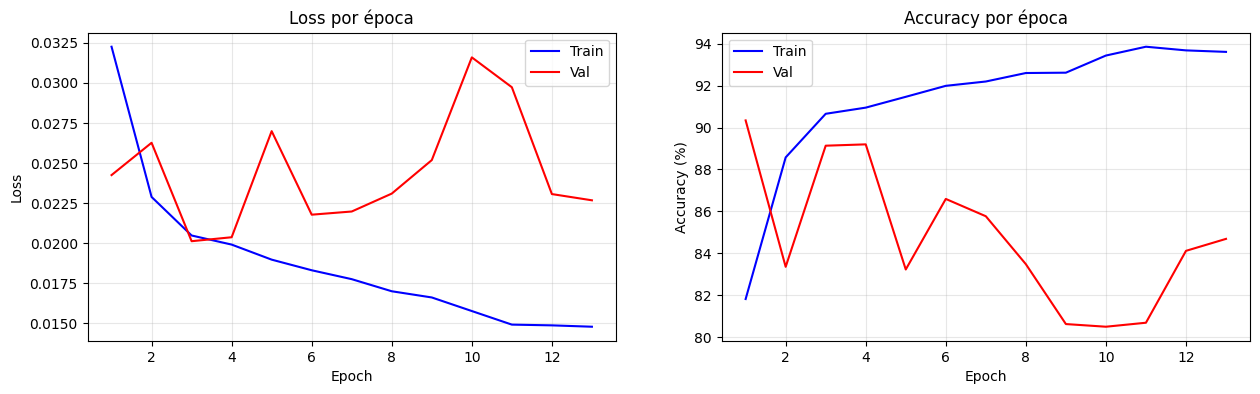

In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

epochs = range(1, len(history['train_loss']) + 1)

# Loss
axes[0].plot(epochs, history['train_loss'], 'b-', label='Train')
axes[0].plot(epochs, history['val_loss'], 'r-', label='Val')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss por época')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs, [a*100 for a in history['train_acc']], 'b-', label='Train')
axes[1].plot(epochs, [a*100 for a in history['val_acc']], 'r-', label='Val')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy por época')
axes[1].legend()
axes[1].grid(True, alpha=0.3)